# Text generation project
This project creates a transformer based model trained on "Shakespeare's Sonnets by William Shakespeare" to generate text. Since most of the code is directly copied from the example given, the bulk of the reporting is at the bottom of this document.

In [38]:
import numpy as np
from tensorflow import keras
import sentencepiece as spm

In [15]:
# read file and remove empty lines
with open('./sonnets.txt', 'r', encoding='utf-8-sig') as file:
    raw = file.read()

# split into separate poems and remove titles
poems = [p for p in raw.split('\n\n') if len(p.strip()) >= 10]
# clean lines
poems = [p.strip() for p in poems if p.strip()]
# rejoin
text = '\n'.join(poems) 

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 95062 characters
First 100 characters: From fairest creatures we desire increase,
That thereby beauty’s rose might never die,
But as the ri


In [28]:
tmp = 'sonnets_tmp.txt'
with open(tmp, 'w', encoding='utf-8') as f:
    f.write('\n'.join(poems))

vocab_size = 3000
model_prefix ='input'

spm.SentencePieceTrainer.train(
    input=tmp,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>'])
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

test_text = "It was upon"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁It', '▁was', '▁upon']
Vocabulary size: 3000


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: sonnets_tmp.txt
  input_format: 
  model_prefix: input
  model_type: BPE
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <PAD>
  user_defined_symbols: <UNK>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_su

In [29]:
# Tokenize the text
seq_length = 128
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

# Create sequences
sequences = []
for i in range(0, len(pieces) - seq_length):
    # Input: first seq_length tokens, Target: next seq_length tokens (shifted by 1)
    sequences.append(pieces[i:i+seq_length+1])

# Convert to NumPy arrays
sequences = np.array(sequences)
inputs = sequences[:, :-1]  # All tokens except the last one
targets = sequences[:, 1:]  # All tokens except the first one

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Split into training and validation sets
indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 24166
Number of sequences: 24038
Input shape: (24038, 128)
Target shape: (24038, 128)


In [30]:
# Cell 5: Define the model
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding

# Define model parameters
embed_dim = 256
num_heads = 4
ff_dim = 512
num_layers = 4

# Create the model
inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding

# Transformer blocks
for _ in range(num_layers):
    # Multi-head attention with causal mask
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x, use_causal_mask=True)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed-forward network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Final output layer
outputs = keras.layers.Dense(sp.get_piece_size())(x)

# Create model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 128, 256)  │    768,000 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 128, 256)  │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 256)  │    263,168 │ add_12[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 128, 256)  │          0 │ add_12[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 256)  │        512 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 128, 256)  │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 128, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 256)  │        512 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 128, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 256)  │        512 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 128, 256)  │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 128, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 256)  │        512 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 128, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten

 Total params: 3,647,416 (13.91 MB)

 Trainable params: 3,647,416 (13.91 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Cell 6: Train the model
batch_size = 128
epochs = 100

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('sonnets_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/100


2026-04-21 14:53:38.199212: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


150/151 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.0633 - loss: 7.3819

2026-04-21 14:54:10.411661: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.0634 - loss: 7.3793

2026-04-21 14:54:19.361779: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_34', 8 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_8', 56 bytes spill stores, 56 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion', 104 bytes spill stores, 104 bytes spill loads

2026-04-21 14:54:20.388680: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-04-21 14:54:23.137280: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


151/151 ━━━━━━━━━━━━━━━━━━━━ 59s 253ms/step - accuracy: 0.0715 - loss: 6.9972 - val_accuracy: 0.0741 - val_loss: 6.4862 - learning_rate: 5.0000e-05
Epoch 2/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 25s 167ms/step - accuracy: 0.0740 - loss: 6.4069 - val_accuracy: 0.0741 - val_loss: 6.3691 - learning_rate: 5.0000e-05
Epoch 3/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 25s 168ms/step - accuracy: 0.0786 - loss: 6.3358 - val_accuracy: 0.0912 - val_loss: 6.2293 - learning_rate: 5.0000e-05
Epoch 4/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 26s 174ms/step - accuracy: 0.1025 - loss: 6.0067 - val_accuracy: 0.1181 - val_loss: 5.7721 - learning_rate: 5.0000e-05
Epoch 5/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 25s 169ms/step - accuracy: 0.1237 - loss: 5.6516 - val_accuracy: 0.1348 - val_loss: 5.4672 - learning_rate: 5.0000e-05
Epoch 6/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 25s 169ms/step - accuracy: 0.1411 - loss: 5.3721 - val_accuracy: 0.1526 - val_loss: 5.1790 - learning_rate: 5.0000e-05
Epoch 7/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 25s 169ms/s

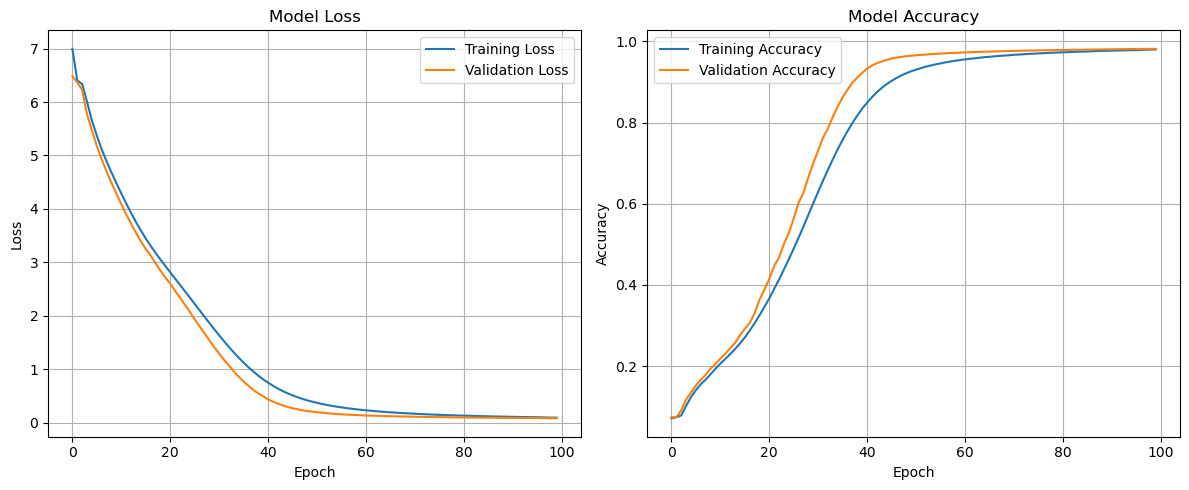

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
model.save('sonnets.keras')

In [34]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """
    Generate text autoregressively.

    Args:
        temperature: Controls randomness
            - Low (0.1-0.5): Focused, repetitive
            - Medium (0.7-1.0): Balanced
            - High (1.5+): Creative, chaotic
    """
    # Encode the prompt
    input_ids = sp.encode_as_ids(prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

# Reporting
## Data selection and preparation
I chose to train my model with Shakespeare's Sonnets collection which includes 154 sonnets that are 14 lines each. I chose this dataset because the collection is very uniform in tone and formatting(each poem is 14 lines). I also tried to use a small dataset to reduce training time enabling more experimentation even if the end result might be worse.  

I also initially tried training the model by modifying it to use individual sonnets as sequences but had trouble getting the model to learn. I suspect the 154 sonnets / 14 lines per sonnet is too small as a dataset to either just use each sonnet as a sequence or fit "moving windows" -type sequences within each sonnet.  

Not much had to be done to prepare the data. I manually removed the Project Gutenberg disclaimers from the .txt file and then removed empty rows and the numbering of the sonnets(was in roman numerals) as seen in the code.  

## Model structure

The base structure is the same as given in the example, which is basically a simple transformer with the following layers:

- embedding + positional embedding
- transformer block (num_layers)
  - multi-head attention
  - add original + multi-head result and normalize
  - FCN (ff_dim)
  - FCN (embed_dim)
  - add original + feed-forward result and normalize
- final output

## Hyperparameters
Hyperparameters used in the final model:
batch_size = 128  
epochs = 100  
embed_dim = 256  
num_heads = 4  
ff_dim = 512  
num_layers = 4  
seq_length = 128  
vocab_size = 3000  

For such a small dataset a small vocabulary size was good (even 2000 seemed reasonable). Below are some sample texts with smaller models. Accuracy got to ~95% even with the smallest model(hyperparameters found below). Widening the embed dimension to 256 and increasing transformer layers to 3 seemed to generate text with a resemblance of coherency.  

The results got better with the final model with 4 layers, increased vocabulary to 3000 and sequence length doubled to 128. Increasing sequence length seemed to help quite a lot, presumably because the format of the sonnets is that each sonnet is like a very long sentence(~120 tokens average). Increasing sequence length also over doubled the training time so the cost is quite high. The largest model seemed to do the formatting and grammar quite well, making the flow similar to the originals.  

Temperatures close to 1.0 seemed to give good results. Lower values were not bad, but higher values seemed to cause the model to start making up words.  

Transformer models are very resource intensive to train of course partly because there are a lot of parameters, but mostly because there are a lot of calculations that have to be done in the multi-head attention layers which makes increasing sequence length increase training time dramatically.

## Example results
Below there are examples of generated text with 3 different versions of the model and varying temperatures.  

#### Fast to train <10 minutes
Prompts with  
batch_size = 128  
epochs = 100  
embed_dim = 192  
num_heads = 4  
ff_dim = 384  
num_layers = 2  
seq_length = 64 
vocab_size = 2000  
produced the results below. This seemed to be around the minimum where you could get coherent results where the grammar is decent even though the content is quite incoherent. The training time was around 10 minutes on my GPU(GTX1060).

In [14]:
"""
prompts = [
    "From the fairest",
    "To the stars"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.0)
    print(generated)
"""


Prompt: From the fairest
From the fairest votary took up afaritation! But when my breast doth master now. So all-tied Muse in manners holds her still, While comments of your praise richly compil’d, Reserve their character with golden quill, And precious phrase by all the Muses filight, where two alone kingdoms power, Thatnd on the riper should by time decease, If this sweet issueless bring him, and therein dign

Prompt: To the stars
To the stars do I my judgement pluck; And yet methinks I have astronom from thee virgin hand disarm’d. Unlearned in the world’s false subtleties. Thus vainly thinking that she think me young, Thou bestowing one, still tell of more, The more doth it nor my verse can forbid? O! none, unless this miracle? Why should my loving thoughts on thee, gentle heart


#### Medium training time 20 minutes
Prompts with
batch_size = 128  
epochs = 100  
embed_dim = 256  
num_heads = 4  
ff_dim = 512  
num_layers = 3  
seq_length = 64  
vocab_size = 2000  
produced the results below. The grammar is similar to above but the content is slightly more coherent. This version took around 20 minutes to train.

In [25]:
"""
prompts = [
    "From the fairest",
    "To the stars"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.0)
    print(generated)
"""


Prompt: From the fairest
From the fairest and favour with presurden of the prime, Like widow’d wombs after their lords’ decease: Yet this abundant issue seem’d to me But hope of orphans, and unfather’d fruit; For summer and his pleasures wait on thee, And, thou away, the very birds are mute: Or, if they sing, ’tis with so dull a cheer, That leaves look pale, dreading the winter’s

Prompt: To the stars
To the stars in secret influence comment; When I perceive that men as plants increase, Cheered and checked even by the self-same sky, Vaunt in their youthful sap, at height decrease, And wear their brave state out of memory; Then the the conceit of this inconstant stay Sets you most rich in youth before my sight, Where wasteful Time debateth with Decay To change your


In [26]:
"""
prompts = [
    "From the fairest",
    "To the stars"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.6)
    print(generated)
"""


Prompt: From the fairest
From the fairest and ucked, to death cannot choose But weep to have, that which it fears to lose. Since brass, nor stone, nor earth, nor boundless sea, But sad mortality o’ersways their power, How with this rage shall beauty hold a plea, Whose action is no stronger than a flower? O! how shall summer’s honey breath hold out, Against the wrackful siege of battering days, When rocks imp

Prompt: To the stars
To the stars twilults on first your slave, I should in thought I honour razed quite, And all the rest forgot for which he toil’d: Then happy I, that love and am belov’d, Where I may not remove nor be remov’d. Lord of my love, to whom in vassalage Thy merit hath my duty strongly knit, To thee I send this written embassage, To witness duty, not to show


In [27]:
"""
prompts = [
    "From the fairest",
    "To the stars"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.3)
    print(generated)
"""


Prompt: From the fairest
From the fairest wis’s hell of time all too cruel: Yet nor the lays of birds, nor the sweet smell Of different flowers in odour and in hue, Could make me any summer’s story tell, Or from their proud lap pluck them where they grew: Nor did I wonder at the lily’s white, Nor praise the deep vermilion in the rose; They were but sweet, but figures of delight, Dr welapp

Prompt: To the stars
To the starsine whereof honour I seen, Three April perfumes in three hot Junes burn’d, Since first I saw you fresh, which yet are green. Ah! yet doth beauty like a dial-hand, Steal from his figure, and no pace perceiv’d; So your sweet hue, which methinks still doth stand, Hath motion, and mine eye may be deceiv’d: For fear of which, hear this thou age unbred: E


#### Largest Model 50 minutes training time
Prompts with 
batch_size = 128  
epochs = 100  
embed_dim = 256  
num_heads = 4  
ff_dim = 512  
num_layers = 4  
seq_length = 128  
vocab_size = 3000  
produced the results below. Increasing vocabulary size and sequence length predictably increased the training time dramatically to ~50 minutes.

In [35]:
prompts = [
    "From the fairest",
    "To the stars"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.6)
    print(generated)


Prompt: From the fairest
From the fairest desire, These present-absent with swift motion slide. For when these quicker elements are gone In tender embassy of love to thee, My life, being made of four, with two alone Sinks down to death, oppress’d with melancholy; Until life’s composition be recur’d By those swift messengers return’d from thee, Who even but now come back again, assur’d, Of thy fair

Prompt: To the stars
To the stars in secret influence comment; When I perceive that men as plants increase, Cheered and checked even by the self-same sky, Vaunt in their youthful sap, at height decrease, And wear their brave state out of memory; Then the conceit of this inconstant stay Sets you most rich in youth before my sight, Where wasteful Time debateth with Decay To change your day of youth to sullied night, And all in war with Time for love


In [36]:
prompts = [
    "From the fairest",
    "To the stars"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.0)
    print(generated)


Prompt: From the fairest
From the fairest and part, The argument, all bare, is of more worth Than when it hath my added praise beside! O! blame me not, if I no more can write! Look in your glass, and there appears a face That over-goes my blunt invention quite, Dulling my lines, and doing me disgrace. Were it not sinful then, striving to mend, To mar the subject that before was well? For to no other pass my verses tend Than of your

Prompt: To the stars
To the stars in And Grant rose, but Time make you look in it doth lie. For as the world an after sun, after sun’s eye, Could make me any summer’s story tell, Or from their proud lap pluck them where they grew: Nor did I wonder at the lily’s white, Nor praise the deep vermilion in the rose; They were but sweet, but figures of delight, Drawn after you, you pattern of all those. Yet


In [37]:
prompts = [
    "From the fairest",
    "To the stars"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.3)
    print(generated)


Prompt: From the fairest
From the fairest desire, These poor rude lines, not to say with thee; But churl interest, Showing their birth, and where they did proceed As I rhyme, And of find liqu pace intent wilful, Diquity. Proving thee that I am the who doth take my pen, shoot not thy as away, foist upon us’d for an end, And kept unused the user so destroys it. No love toward others in that bosom sits That

Prompt: To the stars
To the stars in And dark as the wardrophans, and poor mourners beard, How would be rich, and cur’d in a new wail my poor, And found that minutes waste of evident: For thou art Death to me, that pine to aaintain which to a goddess in? Why should be who have, O! how much say I always write of you, And you and love are still my argument; So all my best is dressing old words new, Sp


### Use of AI
I used AI to help with the text preprocessing, especially when experimenting with diving the sonnets into their own sequences.